<a href="https://colab.research.google.com/github/ao25aaf/multimodal-imdb-genre-classification-keras/blob/main/Multimodal%20IMDb%20Genre%20Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Multimodal IMDb Genre Classification with Keras

## Overview

This project explores a multimodal approach to movie genre classification using both visual and textual data from the IMDb dataset.

Each film is represented by:
- A poster image (JPEG format)
- A textual overview (description)

The task is formulated as a multi-label classification problem, where each film may belong to multiple genres.

![Example](https://i.ibb.co/J3trT62/Screenshot-2024-09-22-214753.png)

Two deep learning models are developed and evaluated independently:

- A Convolutional Neural Network (CNN) for classifying genres based on poster images  
- A Bidirectional Long Short-Term Memory (LSTM) model for classifying genres based on textual overviews  

The objective is to compare how effectively each modality (visual vs textual) captures genre-related patterns and to analyse their performance through both quantitative metrics and qualitative observations.

---

## Project Structure

The workflow for this project is organised into the following stages:

1. Data Processing  
   - Image preprocessing for poster data  
   - Text preprocessing for movie overviews  

2. Model Development  
   - CNN architecture for image-based classification  
   - LSTM architecture for text-based classification  

3. Model Training  

4. Model Evaluation and Analysis  
   - Performance comparison between models  
   - Interpretation of predictions and limitations  

In [ ]:
# Enter your module imports here, some modules are already provided

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
import os
import pathlib
import pandas as pd
from sklearn import model_selection
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from keras.metrics import Precision, Recall
from tensorflow.keras import layers
from tensorflow.keras.layers import Input, Conv2D, Dropout, MaxPooling2D, Flatten, Dense

In [ ]:
# CodeGrade Tag Init1
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# 1. Data Processing



In [ ]:
# CodeGrade Tag Init2
# Do not edit, remove, or copy this cell

# This code will copy the images from your google drive into the colab file
# storage. Make sure the dataset is unzipped in your drive folder.
! mkdir /tmp/Multimodal_IMDB_dataset
! rsync -ah --info=progress2 /content/drive/MyDrive/Multimodal_IMDB_dataset/Images /tmp/Multimodal_IMDB_dataset/

mkdir: cannot create directory ‘/tmp/Multimodal_IMDB_dataset’: File exists
              0   0%    0.00kB/s    0:00:00 (xfr#0, to-chk=0/7897)   


In [ ]:
# CodeGrade Tag Init3
# Do not edit, remove, or copy this cell


# Load the csv with the sample IDs and genres
csv_loc = "/content/drive/MyDrive/Multimodal_IMDB_dataset/IMDB_overview_genres.csv"
dataset = pd.read_csv(csv_loc)

# Split the dataset into training and testing
data_train, data_test = model_selection.train_test_split(dataset, test_size=0.2)

# Convert the labels to arrays
labels_train = np.array(data_train.drop(['Id', 'Genre', 'Overview'],axis=1)).astype('float32')
labels_test = np.array(data_test.drop(['Id', 'Genre', 'Overview'],axis=1)).astype('float32')

# List of the genre names
genres = np.array(data_train.drop(['Id', 'Genre', 'Overview'],axis=1).columns)

# List of overviews
overviews_train = np.array(data_train['Overview'])
overviews_test = np.array(data_test['Overview'])

# Build the file locations for the images
img_loc = "/tmp/Multimodal_IMDB_dataset/Images"

img_locs_train = np.array([[img_loc + '/' + id + '.jpg' for id in data_train['Id']]])
img_locs_test = [[img_loc + '/' + id + '.jpg' for id in data_test['Id']]]


# NOTICE: Provided function
# This function is provided to read in the image files from the folder
def parse_image(filename, label):
  image = tf.io.read_file(filename)
  image = tf.io.decode_jpeg(image)
  return image, label


### 1.a. Image processing of the posters

In [ ]:
# CodeGrade Tag Init4
# Do not edit, remove, or copy this cell

# Create the initial datasets of film posters
list_posters_train_ds = tf.data.Dataset.from_tensor_slices((img_locs_train[0], labels_train))
list_posters_valid_ds = tf.data.Dataset.from_tensor_slices((img_locs_test[0], labels_test))

* **Create a function called ```img_process``` that converts the images to float32 datatype and resizes them to 64x64 pixels.**

In [ ]:
# CodeGrade Tag Ex1a-i

def img_process(image, label):

    #Complete here

    image = tf.image.convert_image_dtype(image,tf.float32)
    image = tf.image.resize(image, [64,64])

    return image, label

* **Create a function called ```img_augment``` that applies appropriate data augmentations to the dataset of movie posters. Choose transformations that you believe will preserve the semantic validity of poster images.**

In [ ]:
# CodeGrade Tag Ex1a-ii

def img_augment(image, label):

    #Complete here

    image = tf.image.random_flip_left_right(image)
    image = tf.image.random_brightness(image, max_delta = 0.1)
    image = tf.image.random_contrast(image, lower = 0.9, upper = 1.1)
    image = tf.image.random_saturation(image, lower = 0.9, upper = 1.1)

    return image, label

* **Using the `tf.data` API, construct the training and validation poster datasets as follows:**
  - For the **training** dataset, apply `parse_image`, then `img_process`, then `img_augment`.
  - For the **validation** dataset, apply `parse_image` and `img_process` (no augmentation).
  - Batch the datasets with batch size `64`.
  - Use appropriate `tf.data` pipeline optimisations (such as shuffling the training data, parallel mapping, and prefetching).

In [ ]:
# CodeGrade Tag Ex1a-iii

AUTOTUNE = tf.data.AUTOTUNE

posters_train_ds = (
    list_posters_train_ds.shuffle(buffer_size = len(labels_train))
    .map(parse_image, num_parallel_calls = AUTOTUNE)
    .map(img_process, num_parallel_calls = AUTOTUNE)
    .cache()
    .map(img_augment, num_parallel_calls = AUTOTUNE)
    .batch(64)
    .prefetch(AUTOTUNE)
)  #Complete here

posters_valid_ds = (
    list_posters_valid_ds
    .map(parse_image, num_parallel_calls = AUTOTUNE)
    .map(img_process, num_parallel_calls = AUTOTUNE)
    .cache()
    .batch(64)
    .prefetch(AUTOTUNE)
) #Complete here

### 1.b. Natural Language processing of the overviews

In [ ]:
# CodeGrade Tag Init5
# Do not edit, remove, or copy this cell

# Create the initial datasets of the film overviews
list_overviews_train_ds = tf.data.Dataset.from_tensor_slices((overviews_train, labels_train))
list_overviews_valid_ds = tf.data.Dataset.from_tensor_slices((overviews_test, labels_test))

* **Using the `tf.data` API, construct the training and validation overviews datasets as follows:**
  - Batch the datasets with batch size `32`.
  - Use appropriate `tf.data` pipeline optimisations such as shuffling the training data and prefetching.

In [ ]:
# CodeGrade Tag Ex1b-i

overviews_train_ds = (
    list_overviews_train_ds.shuffle(buffer_size = len(labels_train))
    .batch(32)
    .prefetch(AUTOTUNE)
)   #Complete here

overviews_valid_ds = (
    list_overviews_valid_ds
    .batch(32)
    .prefetch(AUTOTUNE)
)#Complete here

* Build the vocabulary of the model by calling the ``encoder.adapt()`` method on the film overviews train data.

In [ ]:
# CodeGrade Tag Ex1b-ii

VOCAB_SIZE = 10000

encoder = tf.keras.layers.TextVectorization(
    max_tokens = VOCAB_SIZE,
    output_mode = 'int',
    output_sequence_length = 200
)#Complete here

#Complete here
encoder.adapt(overviews_train_ds.map(lambda text, label: text))

* Print the first 200 words of the vocabulary you obtained.

In [ ]:
# CodeGrade Tag Ex1b-iii

vocabulary = encoder.get_vocabulary() #Complete here

for word in vocabulary[:200]:
  print(word)


[UNK]
a
the
to
of
and
in
his
is
an
with
her
for
he
on
their
who
by
from
when
as
that
after
young
life
they
man
him
at
two
new
but
are
into
has
she
up
woman
family
out
love
one
find
must
friends
be
world
it
finds
school
story
where
them
about
group
girl
have
father
while
home
years
war
town
city
back
wife
during
lives
help
get
becomes
three
boy
all
himself
son
york
high
american
which
team
only
gets
murder
own
time
between
takes
police
mother
former
tries
other
falls
being
against
old
its
down
can
order
friend
become
small
daughter
was
death
college
this
before
save
over
way
together
agent
take
set
will
goes
killer
couple
returns
not
off
through
each
more
husband
first
begins
mysterious
brother
what
relationship
people
living
go
day
work
us
hes
best
meets
house
drug
discovers
now
detective
comes
secret
stop
forced
evil
been
make
four
turns
job
cop
married
trying
just
so
past
men
local
parents
whose
sent
last
another
women
student
series
prison
teenage
sister
movie
than
or
most
wants
ea

## 2. Models Definition

### 2.a. CNN

In this question you will implement a custom Keras layer called `ResidualBlock`.  
This block will be used as the main building unit of the CNN in this section.

A residual block computes two tensors from the same input tensor `x`:

- a **main path** that learns a transformation $F(x)$, and
- a **skip path** that maps the input to a tensor $\mathrm{skip}(x)$ with the same shape as $F(x)$.

These two tensors are then added elementwise, and a final `ReLU` activation is applied:

$$
\mathrm{output} = \mathrm{ReLU}\big(F(x) + \mathrm{skip}(x)\big).
$$

More precisely, the block must have the following architecture.

* Main path

  The main path, corresponding to $F(x)$, must consist of the following layers in this exact order:

  - **3×3 convolution** with:
    - `filters = filters`
    - `strides = strides`
    - `padding = "same"`
    - `activation = "relu"`

  - **Dropout**

  - **3×3 convolution** with:
    - `filters = filters`
    - `strides = 1`
    - `padding = "same"`
    - **no activation function**

  - **Dropout**

* Skip path

  The skip path, corresponding to $\mathrm{skip}(x)$, must consist of a single layer:

  - **1×1 convolution** with:
    - `filters = filters`
    - `strides = strides`
    - `padding = "same"`


* Merge step

  The outputs of the two paths must then be combined as follows:

  - add the outputs elementwise, i.e. $F(x) + \mathrm{skip}(x)$;
  - apply a final ReLU activation to the sum (you can use `layers.ReLU` for this).


Graphically, the whole block will look like the following sketch:

  <img src="https://i.ibb.co/MkVXYFyg/Screenshot-2026-02-06-155017.png" width="300">


#### Implementation notes:
- Define the layers in `__init__` and implement the forward pass in `call`.
- Do not add any extra layers beyond those listed above.
- Recommended: you can use `kernel_initializer="he_normal"` for the convolutional layers, since this is often a good choice with ReLU activations, but this is not mandatory.


In [ ]:
# CodeGrade Tag Ex2a-i

class ResidualBlock(layers.Layer):
    def __init__(self, filters, dropout=0.2, strides=1, name=None):
        super().__init__(name=name)

        # Main path

        self.conv1 = layers.Conv2D(
            filters = filters,
            kernel_size = (3, 3),
            strides = strides,
            padding = 'same',
            activation = 'relu',
            kernel_initializer = 'he_normal'
        )#Complete here

        self.drop1 = layers.Dropout(dropout) #Complete here

        self.conv2 = layers.Conv2D(
            filters = filters,
            kernel_size = (3, 3),
            strides = 1,
            padding = 'same',
            kernel_initializer = 'he_normal'
        )#Complete here

        self.drop2 = layers.Dropout(dropout) #Complete here

        # Skip path

        self.skip = layers.Conv2D(
            filters = filters,
            kernel_size = (1, 1),
            strides = strides,
            padding = 'same',
            kernel_initializer = 'he_normal'
        )#Complete here

        # ReLu layer

        self.relu = layers.ReLU() #Complete here

    def call(self, x, training=False):

        #Complete here

        main = self.conv1(x)
        main = self.drop1(main, training = training)
        main = self.conv2(main)
        main = self.drop2(main, training = training)

        skip = self.skip(x)

        out = self.relu(main + skip)

        return out #Complete here

Using the Keras Functional API, create a convolutional neural network (CNN) that uses the `ResidualBlock` layer you implemented in the previous question.  
This model takes `64×64` RGB movie posters as input and outputs 25 genre probabilities (multi-label classification).

A few important points to consider:

- The input images have shape `(64, 64, 3)`.

- Before the first residual block, apply a convolutional layer called `StemConv` with 32 filters, kernel size `3×3`, `padding="same"`, and `ReLU` activation.

- Use four residual blocks in total, with filter sizes `32, 64, 128, 128`.

- Apply `MaxPooling2D(pool_size=2)` after `Block1`, `Block2`, and `Block3`, but not after `Block4`, so that the spatial dimensions go `64 → 32 → 16 → 8`.

- After the last residual block, use `GlobalAveragePooling2D` (not `Flatten`) to obtain a single feature vector.

- Then use one dense layer `Dense(256, activation="relu")`, followed by `Dropout(0.5)`.

- The output layer must be `Dense(25, activation="sigmoid")` because this is a multi-label classification problem.

- Use the layer names given below so that your model summary matches.

- Do not add any extra top-level layers beyond those listed below.

The following table lists the exact top-level layers of the model:

| Layer name  | Layer type             | Output shape          | Notes                                          |
| ----------- | ---------------------- | --------------------- | ---------------------------------------------- |
| `Input`     | InputLayer             | `(None, 64, 64, 3)`   | Input posters                                  |
| `StemConv`  | Conv2D                 | `(None, 64, 64, 32)`  | 3×3 conv, 32 filters, **ReLU**, padding="same" |
| `Block1`    | ResidualBlock          | `(None, 64, 64, 32)`  | filters=32, dropout=0.2, strides=1             |
| `Pool1`     | MaxPool2D              | `(None, 32, 32, 32)`  | pool_size=2                                    |
| `Block2`    | ResidualBlock          | `(None, 32, 32, 64)`  | filters=64, dropout=0.2, strides=1             |
| `Pool2`     | MaxPool2D              | `(None, 16, 16, 64)`  | pool_size=2                                    |
| `Block3`    | ResidualBlock          | `(None, 16, 16, 128)` | filters=128, dropout=0.2, strides=1            |
| `Pool3`     | MaxPool2D              | `(None, 8, 8, 128)`   | pool_size=2                                    |
| `Block4`    | ResidualBlock          | `(None, 8, 8, 128)`   | filters=128, dropout=0.2, strides=1            |
| `GAP`       | GlobalAveragePooling2D | `(None, 128)`         | averages each 8×8 feature map                  |
| `Dense1`    | Dense                  | `(None, 256)`         | use ReLU as activation function                |
| `DropDense` | Dropout                | `(None, 256)`         | dropout rate = 0.5                             |
| `Output`    | Dense                  | `(None, 25)`          | **sigmoid**                                    |


Recommended: you may use `kernel_initializer="he_normal"` for the convolutional and hidden dense layers, since this often works well with ReLU activations, but this is not mandatory.

In [ ]:
# CodeGrade Tag Ex2a-ii

def build_cnn(num_labels=25, input_shape=(64, 64, 3)):
    inputs = keras.Input(shape=input_shape, name="Input")

    #Complete here

    x = layers.Conv2D(
        32, (3, 3),
        padding="same",
        activation="relu",
        kernel_initializer="he_normal",
        name="StemConv"
    )(inputs)

    x = ResidualBlock(filters=32, dropout=0.2, strides=1, name="Block1")(x)
    x = layers.MaxPooling2D(pool_size=2, name="Pool1")(x)

    x = ResidualBlock(filters=64, dropout=0.2, strides=1, name="Block2")(x)
    x = layers.MaxPooling2D(pool_size=2, name="Pool2")(x)

    x = ResidualBlock(filters=128, dropout=0.2, strides=1, name="Block3")(x)
    x = layers.MaxPooling2D(pool_size=2, name="Pool3")(x)

    x = ResidualBlock(filters=128, dropout=0.2, strides=1, name="Block4")(x)

    x = layers.GlobalAveragePooling2D(name="GAP")(x)
    x = layers.Dense(256, activation="relu", kernel_initializer="he_normal", name="Dense1")(x)
    x = layers.Dropout(0.5, name="DropDense")(x)

    outputs = layers.Dense(num_labels, activation="sigmoid", name="Output")(x)

    model = keras.Model(inputs=inputs, outputs=outputs)

    return model

cnn_model = build_cnn()

* Print the model summary and confirm is has the same architecture as the one provided above.

In [ ]:
# CodeGrade Tag Ex2a-iii

#Complete here

cnn_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Input (InputLayer)              │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ StemConv (Conv2D)               │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Block1 (ResidualBlock)          │ (None, 64, 64, 32)     │        19,552 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Pool1 (MaxPooling2D)            │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Block2 (ResidualBlock)          │ (None, 32, 32, 64)     │        57,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Pool2 (MaxPooling2D)            │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Block3 (ResidualBlock)          │ (None, 16, 16, 128)    │       229,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Pool3 (MaxPooling2D)            │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Block4 (ResidualBlock)          │ (None, 8, 8, 128)      │       311,680 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ GAP (GlobalAveragePooling2D)    │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dense1 (Dense)                  │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ DropDense (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output (Dense)                  │ (None, 25)             │         6,425 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 658,873 (2.51 MB)

 Trainable params: 658,873 (2.51 MB)

 Non-trainable params: 0 (0.00 B)

* **Compile the model using the Adam Optimizer with a learning rate of ```1e-4``` and ```binary crossentropy``` loss function. For the metrics, use the ``Precision`` and ``Recall`` functions.**

In [ ]:
# CodeGrade Tag Ex2a-iv

#Complete here

cnn_model.compile(
    optimizer = tf.keras.optimizers.Adam(learning_rate = 1e-4),
    loss = 'binary_crossentropy',
    metrics = [Precision(), Recall()]
)

### 2.b. LSTM model

* Set up the embedding layer by using ```tf.keras.layers.Embedding```. The ```input_dim``` is the length of the vocab, and the ```output_dim``` must be **265**. You should also set ```mask_zero=True```.

In [ ]:
# CodeGrade Tag Ex2b-i

embedder = tf.keras.layers.Embedding(
    input_dim = len(encoder.get_vocabulary()),
    output_dim = 265,
    mask_zero = True
) #Complete here

* Use ```tf.keras.Sequential``` to build a keras sequential model, with the following layers:



  1.   encoder
  2.   embedder
  3.   biLSTM layer with 256 units, dropout 0.5, recurrent dropout 0.2 (make sure to use the right ```return_sequences``` parametre to be able to stack this layer with the following BiLSTM)
  4.   biLSTM layer with 128 units, dropout 0.5, recurrent dropout 0.2
  5.   dense layer with 128 units and relu activation function
  6.   dropout with rate 0.8
  7.   dense output layer with 25 units and sigmoid activation function



In [ ]:
# CodeGrade Tag Ex2b-ii

lstm_model = tf.keras.Sequential([
    encoder,
    embedder,
    tf.keras.layers.Bidirectional(
        tf.keras.layers.LSTM(
            256,
            dropout = 0.5,
            recurrent_dropout = 0.2,
            return_sequences = True
        )
    ),
    tf.keras.layers.Bidirectional(
        tf.keras.layers.LSTM(
            128,
            dropout = 0.5,
            recurrent_dropout = 0.2
        )
    ),
    tf.keras.layers.Dense(128, activation = 'relu'),
    tf.keras.layers.Dropout(0.8),
    tf.keras.layers.Dense(25, activation = "sigmoid")
]) #Complete here

* Print the model summary and confirm it has the same architecture as the outline provided above.

In [ ]:
# CodeGrade Tag Ex2b-iii

#Complete here
lstm_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ text_vectorization              │ ?                      │   0 (unbuilt) │
│ (TextVectorization)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

* Compile the model with binary crossentropy loss, the adam optimizer, and the accuracy metric

In [ ]:
# CodeGrade Tag Ex2b-iv

#Complete here

lstm_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

# 3. Models Training

* **Create a Model Checkpoint Callback that saves the weights of the best performing epoch, based on the validation loss, for both the CNN and the LSTM**

In [ ]:
# CodeGrade Tag Ex3a-i

checkpoint_cnn_filepath = '/content/checkpoint_cnn.weights.h5'
checkpoint_lstm_filepath = '/content/checkpoint_lstm.weights.h5'

from tensorflow.keras.callbacks import ModelCheckpoint

checkpoint_cnn_callback = ModelCheckpoint(
    filepath=checkpoint_cnn_filepath,
    monitor="val_loss",
    save_best_only=True,
    save_weights_only=True,
    mode="min",
    verbose=1
)#Complete here

checkpoint_lstm_callback = ModelCheckpoint(
    filepath=checkpoint_lstm_filepath,
    monitor="val_loss",
    save_best_only=True,
    save_weights_only=True,
    mode="min",
    verbose=1
)#Complete here


### 3.a. CNN training

* **Train the CNN model for 50 epochs, using the callbacks you made previously. Store the losses and metrics to use later.**

In [ ]:
# CodeGrade Tag Ex3a

cnn_history = cnn_model.fit(
    posters_train_ds,
    validation_data=posters_valid_ds,
    epochs=50,
    callbacks=[checkpoint_cnn_callback]
)#Complete here

Epoch 1/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step - loss: 1.2810 - precision: 0.1469 - recall: 0.3620
Epoch 1: val_loss improved from None to 0.40437, saving model to /content/checkpoint_cnn.weights.h5

Epoch 1: finished saving model to /content/checkpoint_cnn.weights.h5
80/80 ━━━━━━━━━━━━━━━━━━━━ 30s 198ms/step - loss: 0.6604 - precision: 0.1885 - recall: 0.3252 - val_loss: 0.4044 - val_precision: 0.5183 - val_recall: 0.2465
Epoch 2/50
79/80 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 0.3296 - precision: 0.3264 - recall: 0.2678
Epoch 2: val_loss improved from 0.40437 to 0.38189, saving model to /content/checkpoint_cnn.weights.h5

Epoch 2: finished saving model to /content/checkpoint_cnn.weights.h5
80/80 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - loss: 0.3193 - precision: 0.3515 - recall: 0.2630 - val_loss: 0.3819 - val_precision: 0.5667 - val_recall: 0.3288
Epoch 3/50
79/80 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 0.2966 - precision: 0.4039 - recall: 0.2663
Epoch 3: val_loss improved from 0

### 3.b. LSTM training

* **Train the model for 20 epochs** (this may take several minutes)**, using the callbacks you made previously. Store the losses and metrics to use later.**

In [ ]:
# CodeGrade Tag Ex3b

lstm_history = lstm_model.fit(
    overviews_train_ds,
    validation_data=overviews_valid_ds,
    epochs=20,
    callbacks=[checkpoint_lstm_callback]
) #Complete here

Epoch 1/20
159/159 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.1445 - loss: 0.4439
Epoch 1: val_loss improved from None to 0.23854, saving model to /content/checkpoint_lstm.weights.h5

Epoch 1: finished saving model to /content/checkpoint_lstm.weights.h5
159/159 ━━━━━━━━━━━━━━━━━━━━ 363s 2s/step - accuracy: 0.1903 - loss: 0.3538 - val_accuracy: 0.2024 - val_loss: 0.2385
Epoch 2/20
159/159 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.2244 - loss: 0.2737
Epoch 2: val_loss improved from 0.23854 to 0.22982, saving model to /content/checkpoint_lstm.weights.h5

Epoch 2: finished saving model to /content/checkpoint_lstm.weights.h5
159/159 ━━━━━━━━━━━━━━━━━━━━ 349s 2s/step - accuracy: 0.2332 - loss: 0.2664 - val_accuracy: 0.2016 - val_loss: 0.2298
Epoch 3/20
159/159 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.2536 - loss: 0.2485
Epoch 3: val_loss improved from 0.22982 to 0.22143, saving model to /content/checkpoint_lstm.weights.h5

Epoch 3: finished saving model to /content/checkpoint_lst

### 3.c. Load the best weights

* Now, load the best weights from your checkpoints of both your models.

In [ ]:
# CodeGrade Tag Ex3c

#Complete here

# Load best weights for CNN
cnn_model.load_weights(checkpoint_cnn_filepath)

# Load best weights for LSTM
lstm_model.load_weights(checkpoint_lstm_filepath)

# 4. Models Evaluation

### 4.a. CNN Evaluation

* **Create plots using the losses and metrics. In your report, discuss these results and critically evaluate the model performance.**

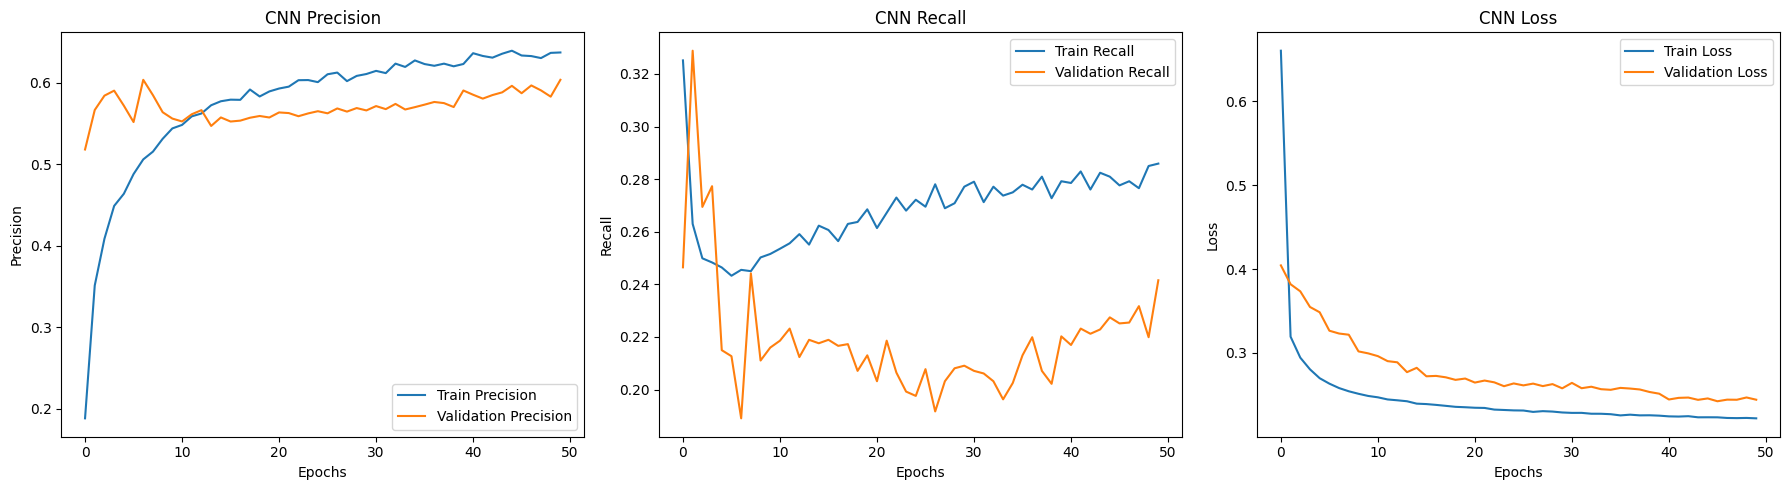

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# CodeGrade Tag Ex4a-i

#Complete here

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Precision plot
axes[0].plot(cnn_history.history['precision'], label='Train Precision')
axes[0].plot(cnn_history.history['val_precision'], label='Validation Precision')
axes[0].set_title('CNN Precision')
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Precision')
axes[0].legend()

# Recall plot
axes[1].plot(cnn_history.history['recall'], label='Train Recall')
axes[1].plot(cnn_history.history['val_recall'], label='Validation Recall')
axes[1].set_title('CNN Recall')
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('Recall')
axes[1].legend()

# Loss plot
axes[2].plot(cnn_history.history['loss'], label='Train Loss')
axes[2].plot(cnn_history.history['val_loss'], label='Validation Loss')
axes[2].set_title('CNN Loss')
axes[2].set_xlabel('Epochs')
axes[2].set_ylabel('Loss')
axes[2].legend()

plt.tight_layout()
plt.savefig("cnn_evaluation_plots.png", dpi=300, bbox_inches="tight")
plt.show()

from google.colab import files
files.download("cnn_evaluation_plots.png")

### 4.b. LSTM Evaluation

* **Create plots using the losses and metrics. In your report, discuss these results and critically evaluate the model performance.**

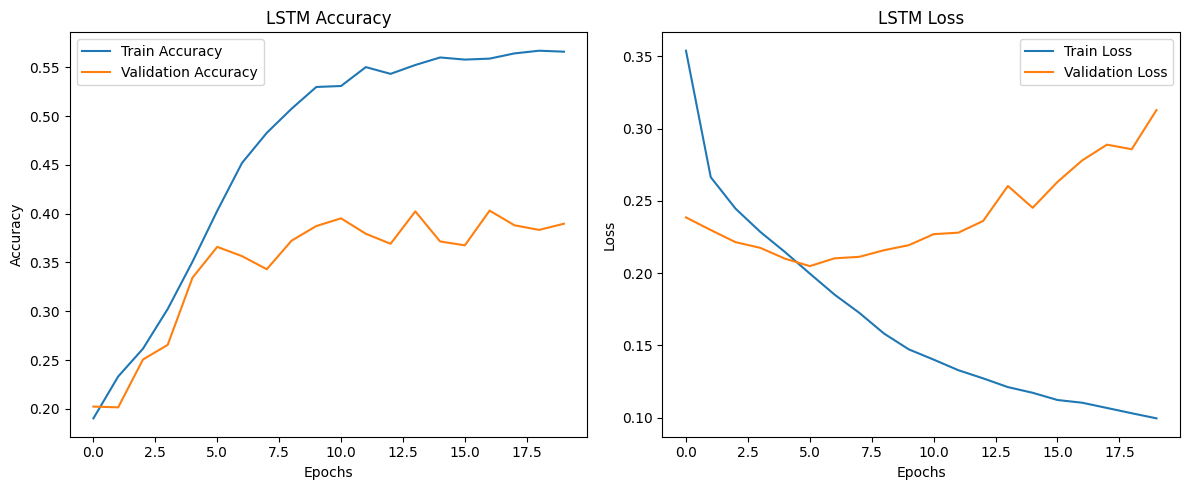

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# CodeGrade Tag Ex4b-i

#Complete here

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(lstm_history.history['accuracy'], label='Train Accuracy')
axes[0].plot(lstm_history.history['val_accuracy'], label='Validation Accuracy')
axes[0].set_title('LSTM Accuracy')
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

axes[1].plot(lstm_history.history['loss'], label='Train Loss')
axes[1].plot(lstm_history.history['val_loss'], label='Validation Loss')
axes[1].set_title('LSTM Loss')
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.savefig("lstm_evaluation_plots.png", dpi=300, bbox_inches="tight")
plt.show()

from google.colab import files
files.download("lstm_evaluation_plots.png")

### 4.c. Produce examples for the report

* Choose a few films from the dataset, plot their posters and print their overviews. Use these example films to demonstrate the classification performance of the CNN model on their posters and of the LSTM model on their overview.

* Be sure to demonstrate the results of the multi-label classification. Compare, for each example film, the top three most probable genres predicted by the CNN and the top three most probable genres predicted by the LSTM with the ground truth genres.

* Include these examples in your report, and critically evaluate the performance of the model across the classes.

* Morevoer, you are allowed to add any other plot that could support your analysis, e.g. a confusion matrix.

**For this task, you can add new cells as you please.**

### Qualitative and Comparative Evaluation Configuration

In this section, I look at how the two models behave on individual films rather than focusing on aggregate metrics such as loss, precision, recall and accuracy. This is very important since the model's performance in a multi-label classification setting cannot be fully shown by overall metrics alone.

The goal here is to set up functions that allows to:

*   extract each movies actual genre from the label vector,
*   identify each model's top predicted genres,
*   process one poster image for CNN prediction, and
*   gather the relevant outputs so they may be compared side by side.

This will enable analysis of specific examples  in a structured way and a direct comparison of the CNN and LSTM predictions against the ground truth labels.




In [ ]:
import textwrap

genres = np.array(genres)

# List of true genre names for a single film
def get_true_genres(label_vector, genres):
    return list(genres[np.where(label_vector == 1)[0]])

# Top k predicted genres with their probabilities
def get_top_k_predictions(probabilities, genres, k=3):
    top_idx = np.argsort(probabilities)[-k:][::-1]
    return [(genres[i], float(probabilities[i])) for i in top_idx]
# Add a 'yes' if predicted genre is correct and a 'no' if it is not
def format_top_k(preds, true_genres):
    formatted = []
    for genre, prob in preds:
        mark = "yes" if genre in true_genres else "no"
        formatted.append(f"{genre} ({prob:.3f}) {mark}")
    return formatted

# Load, decode, scale, and resize a single poster image
def process_single_image(img_path):
    image = tf.io.read_file(img_path)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.convert_image_dtype(image, tf.float32)
    image = tf.image.resize(image, [64, 64])
    return image

# Collect all relevant information
def predict_single_example(idx):
    img_path = img_locs_test[0][idx]
    overview = overviews_test[idx]
    true_labels = labels_test[idx]
    true_genres = get_true_genres(true_labels, genres)

    image = process_single_image(img_path)

    cnn_probs = cnn_model.predict(tf.expand_dims(image, axis=0), verbose=0)[0]
    lstm_probs = lstm_model.predict(tf.constant([overview]), verbose=0)[0]

    cnn_top3 = get_top_k_predictions(cnn_probs, genres, k=3)
    lstm_top3 = get_top_k_predictions(lstm_probs, genres, k=3)

    return {
        "idx": idx,
        "image": image,
        "overview": overview,
        "true_genres": true_genres,
        "cnn_top3": cnn_top3,
        "lstm_top3": lstm_top3,
        "cnn_probs": cnn_probs,
        "lstm_probs": lstm_probs
    }

### Getting the Best Saved Weights

I load the best-performing weights fpr both models from the checkpoints created during traing before producing example predictions.

The last epoch isn't always the best, so this step is actually crucial. In both CNN and LSTM training, the model weights from the epoch with the best validation performance were saved at the checkpoint, and the validation loss was tracked.

I ensure that the charts and examples in this section represent the strongest version of each model, not just the last epoch, by loading these saved weights.

In [ ]:
# Load best weights before example generation

cnn_model.load_weights(checkpoint_cnn_filepath)
lstm_model.load_weights(checkpoint_lstm_filepath)

## Choosing Example Films

I select a small number of films from the test set for in-depth examination in order to make the analysis concrete.

These examples are utilised to:

*   Show the poster image
*   print the text overview
*   compare the actual genres with the top three CNN-predicted genres, and
*   compare the same film to the top three LSTM-predicted genres.



In [ ]:
# Choosing examples

example_indices = [0, 10, 25, 50, 100]
example_results = [predict_single_example(idx) for idx in example_indices]

### Qualitative Comparison Based on Example

A detailed comparison of a few selected films is presented in this section.

For each instance, I demonstrate:

*   the image on the poster,
*   the ground truth genres
*   the text overview,
*   CNN's top three genre predictions based on the poster, and
*   compare the same film to the top three LSTM-predicted genres.

I use this type of qualitative analysis because it shows not just that a model is right or wrong, but also shows how close its predictions are to the ground truth.


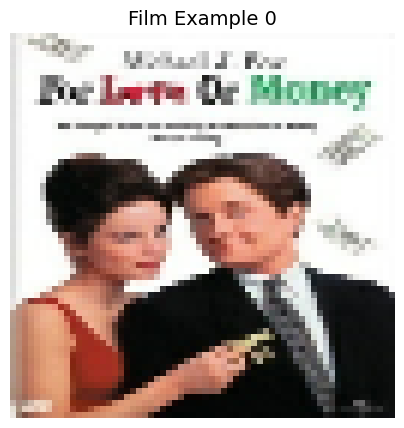

FILM INDEX: 0
GROUND TRUTH GENRES: Comedy, Drama, Romance

OVERVIEW:
Doug's a concierge at a luxury hotel on Manhattan. He saves all his tips towards his plan for a hotel. A
potential investor seduces the girl, Doug loves, with false promises of leaving his wife. Doug's dilemma:
hotel project or girl?

CNN TOP 3 PREDICTIONS:
  - Drama (0.647) yes
  - Romance (0.356) yes
  - Comedy (0.342) yes

LSTM TOP 3 PREDICTIONS:
  - Drama (0.647) yes
  - Comedy (0.632) yes
  - Romance (0.555) yes

CNN top-3 hits: 3/3
LSTM top-3 hits: 3/3



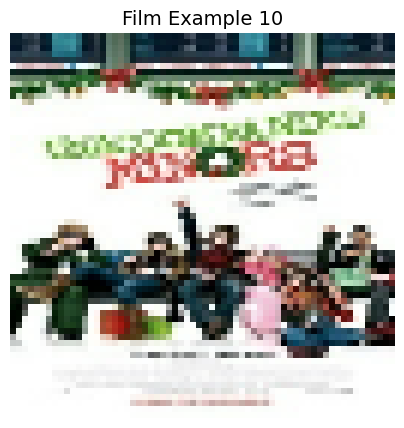

FILM INDEX: 10
GROUND TRUTH GENRES: Adventure, Comedy, Family

OVERVIEW:
A group of unaccompanied minors bond while snowed in at the midwestern Hoover International Airport during the
holiday season and ultimately create a makeshift holiday themselves.

CNN TOP 3 PREDICTIONS:
  - Drama (0.631) no
  - Comedy (0.332) yes
  - Romance (0.298) no

LSTM TOP 3 PREDICTIONS:
  - Drama (0.540) no
  - Action (0.323) no
  - Comedy (0.279) yes

CNN top-3 hits: 1/3
LSTM top-3 hits: 1/3



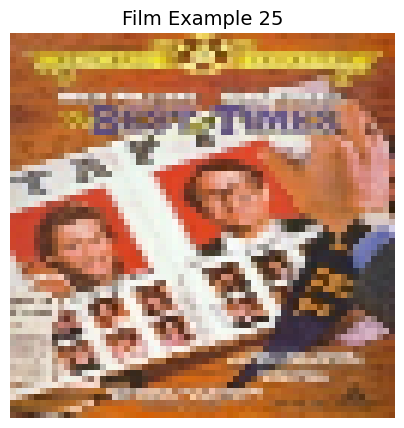

FILM INDEX: 25
GROUND TRUTH GENRES: Comedy, Drama, Sport

OVERVIEW:
A small-town loser determines to have one more shot at the big time by winning a football game.

CNN TOP 3 PREDICTIONS:
  - Comedy (0.584) yes
  - Drama (0.499) yes
  - Romance (0.371) no

LSTM TOP 3 PREDICTIONS:
  - Drama (0.581) yes
  - Comedy (0.579) yes
  - Romance (0.419) no

CNN top-3 hits: 2/3
LSTM top-3 hits: 2/3



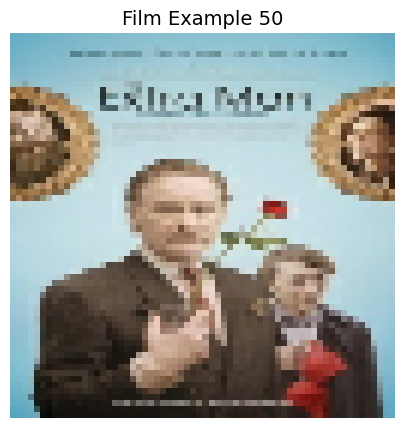

FILM INDEX: 50
GROUND TRUTH GENRES: Comedy

OVERVIEW:
A man who escorts wealthy widows in New York's Upper East Side takes a young aspiring playwright under his
wing.

CNN TOP 3 PREDICTIONS:
  - Drama (0.625) no
  - Comedy (0.306) yes
  - Romance (0.276) no

LSTM TOP 3 PREDICTIONS:
  - Drama (0.773) no
  - Comedy (0.553) yes
  - Romance (0.342) no

CNN top-3 hits: 1/3
LSTM top-3 hits: 1/3



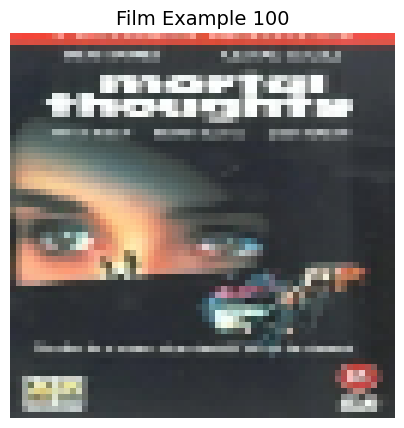

FILM INDEX: 100
GROUND TRUTH GENRES: Mystery, Thriller

OVERVIEW:
Two detectives interrogate a hairdresser on two homicides she may or may not have been involved in.

CNN TOP 3 PREDICTIONS:
  - Drama (0.581) no
  - Horror (0.356) no
  - Thriller (0.306) yes

LSTM TOP 3 PREDICTIONS:
  - Drama (0.627) no
  - Crime (0.446) no
  - Comedy (0.351) no

CNN top-3 hits: 1/3
LSTM top-3 hits: 0/3



In [ ]:
for result in example_results:
    idx = result["idx"]
    image = result["image"]
    overview = result["overview"]
    true_genres = result["true_genres"]
    cnn_top3 = result["cnn_top3"]
    lstm_top3 = result["lstm_top3"]

    plt.figure(figsize=(5, 5))
    plt.imshow(image)
    plt.axis("off")
    plt.title(f"Film Example {idx}", fontsize=14)
    plt.show()

    print("=" * 120)
    print(f"FILM INDEX: {idx}")
    print(f"GROUND TRUTH GENRES: {', '.join(true_genres)}")
    print()

    print("OVERVIEW:")
    print(textwrap.fill(overview, width=110))
    print()

    print("CNN TOP 3 PREDICTIONS:")
    for item in format_top_k(cnn_top3, true_genres):
        print("  -", item)
    print()

    print("LSTM TOP 3 PREDICTIONS:")
    for item in format_top_k(lstm_top3, true_genres):
        print("  -", item)

    cnn_hits = sum([1 for g, _ in cnn_top3 if g in true_genres])
    lstm_hits = sum([1 for g, _ in lstm_top3 if g in true_genres])

    print()
    print(f"CNN top-3 hits: {cnn_hits}/3")
    print(f"LSTM top-3 hits: {lstm_hits}/3")
    print("=" * 120)
    print()

### Summary comparison table of Example Films

I summarise the selected examples in a table to make comparison much easier to read.

This  offers a compact summary of the selected film's qualitative performace.

In [ ]:
example_summary = []

for result in example_results:
    idx = result["idx"]
    true_genres = result["true_genres"]
    cnn_top3 = [g for g, _ in result["cnn_top3"]]
    lstm_top3 = [g for g, _ in result["lstm_top3"]]

    cnn_hits = sum(g in true_genres for g in cnn_top3)
    lstm_hits = sum(g in true_genres for g in lstm_top3)

    if cnn_hits > lstm_hits:
        comment = "CNN stronger"
    elif lstm_hits > cnn_hits:
        comment = "LSTM stronger"
    elif cnn_hits == 0 and lstm_hits == 0:
        comment = "Both weak"
    else:
        comment = "Similar performance"

    example_summary.append({
        "Film Index": idx,
        "Ground Truth": ", ".join(true_genres),
        "CNN Top 3": ", ".join(cnn_top3),
        "LSTM Top 3": ", ".join(lstm_top3),
        "CNN Hits": cnn_hits,
        "LSTM Hits": lstm_hits,
        "Comment": comment
    })

example_df = pd.DataFrame(example_summary)
example_df

,Film Index,Ground Truth,CNN Top 3,LSTM Top 3,CNN Hits,LSTM Hits,Comment
0,0,"Comedy, Drama, Romance","Drama, Romance, Comedy","Drama, Comedy, Romance",3,3,Similar performance
1,10,"Adventure, Comedy, Family","Drama, Comedy, Romance","Drama, Action, Comedy",1,1,Similar performance
2,25,"Comedy, Drama, Sport","Comedy, Drama, Romance","Drama, Comedy, Romance",2,2,Similar performance
3,50,Comedy,"Drama, Comedy, Romance","Drama, Comedy, Romance",1,1,Similar performance
4,100,"Mystery, Thriller","Drama, Horror, Thriller","Drama, Crime, Comedy",1,0,CNN stronger


The CNN and LSTM perform broadly similarly accross the selected examples. With the top three predictions, each model typically identifies one correct genre; in two seperate instances, both models identify 2 correct genres and 3 correct genres for Film 25 and Film 0 respectively. The biggest difference can be seen in Film 100, where the LSTM fails to recover any true labels but the CNN is able to capture one. This implies that stronger visual cues in the poster may improve the CNN's performance.

Overall, the model performs moderately, generating multi-label predictions that are partially correct but not entirely comprehensive and reflect the fact that neither model consistently captures all ground-truth labels.

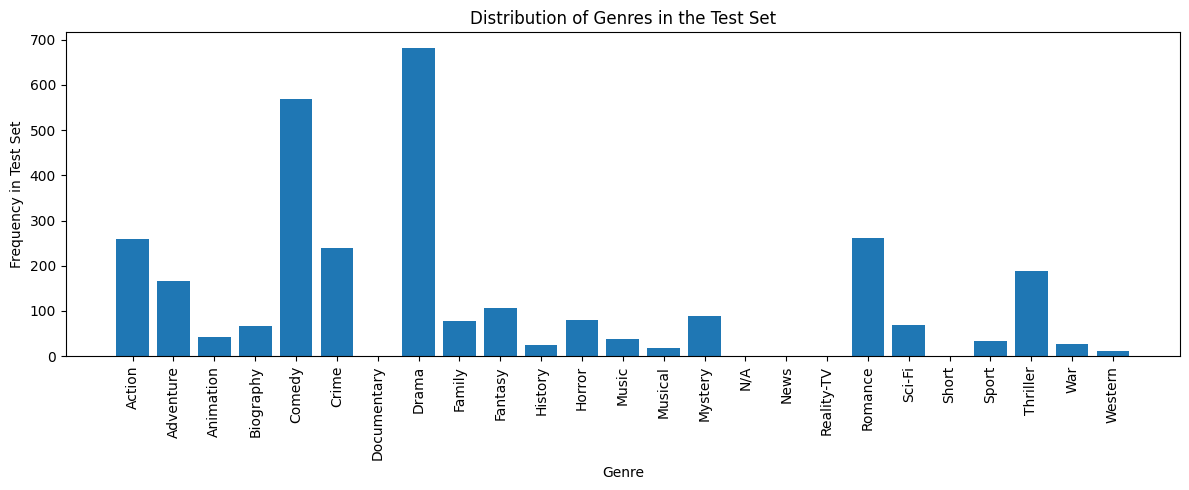

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
genre_counts = labels_test.sum(axis=0)

plt.figure(figsize=(12, 5))
plt.bar(genres, genre_counts)
plt.xticks(rotation=90)
plt.xlabel("Genre")
plt.ylabel("Frequency in Test Set")
plt.title("Distribution of Genres in the Test Set")
plt.tight_layout()
plt.savefig("genre_distribution_test_set.png", dpi=300, bbox_inches="tight")
plt.show()

from google.colab import files
files.download("genre_distribution_test_set.png")

The test-set genre distribution is extremely uneven, with genre like Drama and Comedy appearing much more frequently than many others. A hand-ful of genres rarely occur, and this causes imbalance because models trained on such data are more likely to learn dominant classess effectively while struggling with infrequent genres.

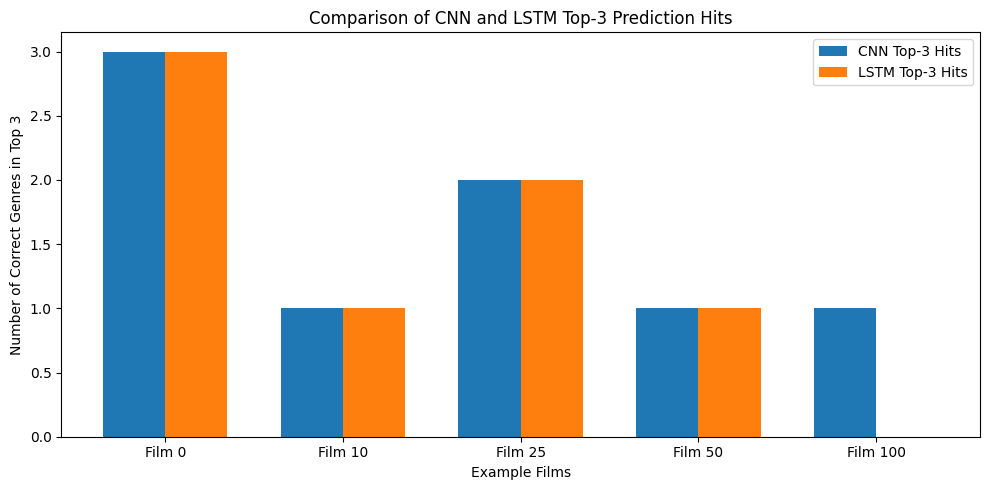

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
cnn_hits_list = []
lstm_hits_list = []

for result in example_results:
    true_genres = result["true_genres"]
    cnn_top3 = [g for g, _ in result["cnn_top3"]]
    lstm_top3 = [g for g, _ in result["lstm_top3"]]

    cnn_hits_list.append(sum(g in true_genres for g in cnn_top3))
    lstm_hits_list.append(sum(g in true_genres for g in lstm_top3))

x = np.arange(len(example_results))
width = 0.35

plt.figure(figsize=(10, 5))
plt.bar(x - width/2, cnn_hits_list, width, label="CNN Top-3 Hits")
plt.bar(x + width/2, lstm_hits_list, width, label="LSTM Top-3 Hits")
plt.xticks(x, [f"Film {r['idx']}" for r in example_results])
plt.xlabel("Example Films")
plt.ylabel("Number of Correct Genres in Top 3")
plt.title("Comparison of CNN and LSTM Top-3 Prediction Hits")
plt.legend()
plt.tight_layout()
plt.savefig("cnn_lstm_top3_hits.png", dpi=300, bbox_inches="tight")
plt.show()

from google.colab import files
files.download("cnn_lstm_top3_hits.png")

### Comparison between the Predicted and the True Genre Frequencies

To support the class-level analysis further, I compare the ground truth frequency of each genre in the test set with how frequently each model predicts that genre.

This helps in providing answers to important queries like:

*   Are some genres under-predicted by a model?
*   Does it over-predict some genres?
*   Are some genres significatly easier for one model than the other?

Instead of concentrating simply on isolated instances, this plot is particularly useful for identifying systemic tendencies across classes.

20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step
40/40 ━━━━━━━━━━━━━━━━━━━━ 16s 373ms/step


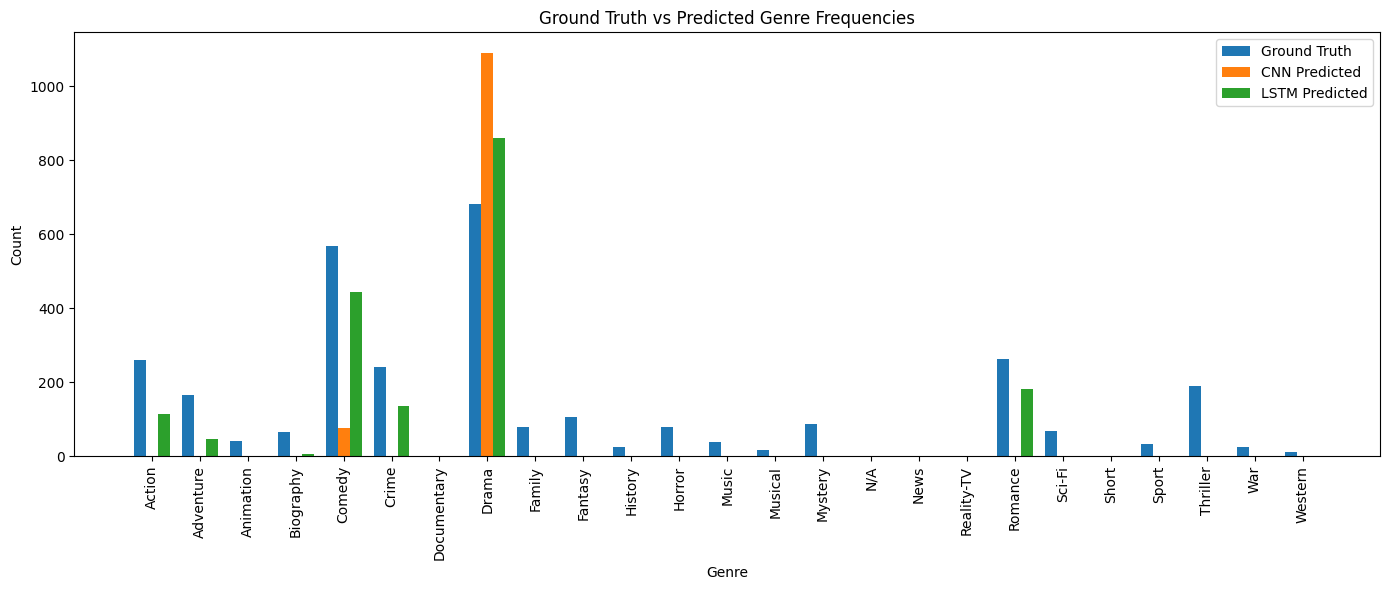

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
cnn_pred_labels = (cnn_model.predict(posters_valid_ds) >= 0.5).astype(int)
lstm_pred_labels = (lstm_model.predict(overviews_valid_ds) >= 0.5).astype(int)

true_counts = labels_test.sum(axis=0)
cnn_pred_counts = cnn_pred_labels.sum(axis=0)
lstm_pred_counts = lstm_pred_labels.sum(axis=0)

x = np.arange(len(genres))
width = 0.25

plt.figure(figsize=(14, 6))
plt.bar(x - width, true_counts, width, label="Ground Truth")
plt.bar(x, cnn_pred_counts, width, label="CNN Predicted")
plt.bar(x + width, lstm_pred_counts, width, label="LSTM Predicted")
plt.xticks(x, genres, rotation=90)
plt.xlabel("Genre")
plt.ylabel("Count")
plt.title("Ground Truth vs Predicted Genre Frequencies")
plt.legend()
plt.tight_layout()
plt.savefig("ground_truth_vs_predicted_frequencies.png", dpi=300, bbox_inches="tight")
plt.show()

from google.colab import files
files.download("ground_truth_vs_predicted_frequencies.png")

The figure (Ground Truth vs Predicted Genre Frequencies) shows that both models are skewed towards the few dominant genres, particularly drama, when we look at the frequency comparison. The CNN predicts Drama significantly more frequently than its true freqquency, while many other genres are predicted extremely infrequently. Even if the LSTM is a little less extreme, it still under predicts many classes.

This is consistent with the dataset's class imbalance and suggests that both models are better at learning common genre patterns than at identifying widespread genre patterns .

Overall, this suggests that although the models are able to recognise dominating  patterns in the data, they are less effective at identifying genres that are more subtle or rare.